# Modelo PointNet

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install lazrs laszip laspy paho-mqtt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.2/627.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 4.3 MB/s eta 0:00:00


In [3]:
import os
import laspy
import numpy as np
import pandas as pd
from skimage.transform import resize

In [4]:
# Pegamos cada talhão dos dados LiDAR coletados
laz_files = sorted([
    f for f in os.listdir("/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR")
    if f.endswith(".laz")
])

print(laz_files)

['SaoManuelTotal_001.laz', 'SaoManuelTotal_002.laz', 'SaoManuelTotal_004.laz', 'SaoManuelTotal_005.laz', 'SaoManuelTotal_006.laz', 'SaoManuelTotal_007.laz']


In [5]:
# Criamos listas para armazenar os pontos, o valor real da altura, os IDs de cada parcela dentro dos talhões e os IDs dos talhões
X_points = []
y_dap = []
parcelas_ids = []
talhoes_ids = []

In [6]:
import geopandas as gpd

gdf = gpd.read_file(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/shapes/Parcelas/parcelas.shp"
)

gdf["talhao"] = (
    gdf["talhao"]
    .astype(str)
    .str.zfill(3)
)

gdf["parcela"] = (
    gdf["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(gdf.head())

print(gdf["talhao"].unique())

   id     elev parcela talhao     Fazenda        Especie Mat_gen  \
0   1  738.637     001    001  São Manuel  Eucalyptus sp    I144   
1   2  739.195     002    001  São Manuel  Eucalyptus sp    I144   
2   3  774.722     003    003  São Manuel           None    None   
3   4  781.896     004    004  São Manuel  Eucalyptus sp    None   
4   5  776.755     005    004  São Manuel  Eucalyptus sp    None   

                                   geometry  
0  POINT Z (749049.463 7480009.299 738.637)  
1   POINT Z (748983.36 7480013.776 739.195)  
2  POINT Z (748849.993 7479561.952 774.722)  
3  POINT Z (748836.068 7479441.914 781.896)  
4  POINT Z (748827.399 7479324.807 776.755)  
['001' '003' '004' '002' '005' '008' '006' '007']


In [7]:
# Utilizamos 2048 pontos e essa função garante que a seed seja fixa, a fim de garantir a reprodutibilidade da proposta.
def sample_points(points, n_points=2048, seed=42):
    rng = np.random.default_rng(seed)
    if len(points) >= n_points:
        idx = rng.choice(
            len(points),
            n_points,
            replace=False
        )
    else:
        idx = rng.choice(
            len(points),
            n_points,
            replace=True
        )
    return points[idx]

In [8]:
# Essa função realiza a normação dos pontos pelo centroide e calculando a distância com max_dist possibilita que os pontos fiquem mais homogêneos para calculo do DAP
def normalize_points(points):
    centroid = np.mean(points, axis=0)
    points = points - centroid

    max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
    points = points / max_dist

    return points

In [9]:
# Abrimos o DAP real medido em campo para cada parcela
df = pd.read_csv(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/SaoManuelTotal_08022025_plot_metric.csv"
)

df["parcela"] = (
    df["parcela"]
    .astype(str)
    .str.zfill(3)
)

print(df[["parcela", "D_cm"]].head())

  parcela  D_cm
0     001  17.6
1     002  16.8
2     004  12.9
3     005  13.8
4     006  13.8


In [10]:
X_points = []
parcelas_ids = []
y_dap = []
talhoes_ids = []

for laz_file in laz_files:
    print("Processando dados LiDAR:", laz_file)

    talhao = laz_file.split("_")[-1].replace(".laz","")

    las_path = os.path.join(
        "/content/drive/MyDrive/IoT/Dados/SaoManuel/Talhoes/SaoManuel_LIDAR",
        laz_file
    )

    las = laspy.read(las_path)

    x_lidar = np.array(las.x)
    y_lidar = np.array(las.y)
    z_lidar = np.array(las.z)

    points_all = np.vstack(
        (x_lidar, y_lidar, z_lidar)
    ).transpose()

    gdf_talhao = gdf[
        gdf["talhao"] == talhao
    ]

    print("Parcelas:", len(gdf_talhao))

    for idx, row in gdf_talhao.iterrows():

        geom = row.geometry

        cx = geom.x
        cy = geom.y

        radius = 11.28

        dist = np.sqrt(
            (x_lidar - cx)**2 +
            (y_lidar - cy)**2
        )

        mask = dist <= radius

        crop = points_all[mask]

        if len(crop) < 500:
            continue

        crop = sample_points(
            crop,
            n_points=2048,
            seed=42
        )

        crop = normalize_points(crop)

        parcela = str(
            row["parcela"]
        ).zfill(3)

        dap_row = df[
            df["parcela"] == parcela
        ]

        if len(dap_row) == 0:
            continue

        dap = dap_row["D_cm"].values[0]

        X_points.append(crop)
        y_dap.append(dap)
        parcelas_ids.append(parcela)
        talhoes_ids.append(talhao)
        print(
            f"Parcela {parcela}"
            f" - pontos {crop.shape}"
            f" DAP = {dap}"
        )

Processando dados LiDAR: SaoManuelTotal_001.laz
Parcelas: 2
Parcela 001 - pontos (2048, 3) DAP = 17.6
Parcela 002 - pontos (2048, 3) DAP = 16.8
Processando dados LiDAR: SaoManuelTotal_002.laz
Parcelas: 2
Parcela 006 - pontos (2048, 3) DAP = 13.8
Parcela 007 - pontos (2048, 3) DAP = 16.0
Processando dados LiDAR: SaoManuelTotal_004.laz
Parcelas: 2
Parcela 004 - pontos (2048, 3) DAP = 12.9
Parcela 005 - pontos (2048, 3) DAP = 13.8
Processando dados LiDAR: SaoManuelTotal_005.laz
Parcelas: 2
Parcela 008 - pontos (2048, 3) DAP = 17.6
Parcela 009 - pontos (2048, 3) DAP = 16.7
Processando dados LiDAR: SaoManuelTotal_006.laz
Parcelas: 3
Parcela 010 - pontos (2048, 3) DAP = 17.8
Parcela 011 - pontos (2048, 3) DAP = 17.0
Parcela 012 - pontos (2048, 3) DAP = 17.4
Processando dados LiDAR: SaoManuelTotal_007.laz
Parcelas: 2
Parcela 013 - pontos (2048, 3) DAP = 17.4
Parcela 014 - pontos (2048, 3) DAP = 20.4


In [11]:
X_points = np.array(X_points)
y_dap = np.array(y_dap)
parcelas_ids = np.array(parcelas_ids)
talhoes_ids = np.array(talhoes_ids)

print("X:", X_points.shape)
print("y:", y_dap.shape)
print("Parcelas:", parcelas_ids.shape)
print("Talhões:", talhoes_ids.shape)

X: (13, 2048, 3)
y: (13,)
Parcelas: (13,)
Talhões: (13,)


In [12]:
X_points = np.array(X_points)
y_dap = np.array(y_dap)

In [13]:
print(X_points.shape)
print(y_dap.shape)

(13, 2048, 3)
(13,)


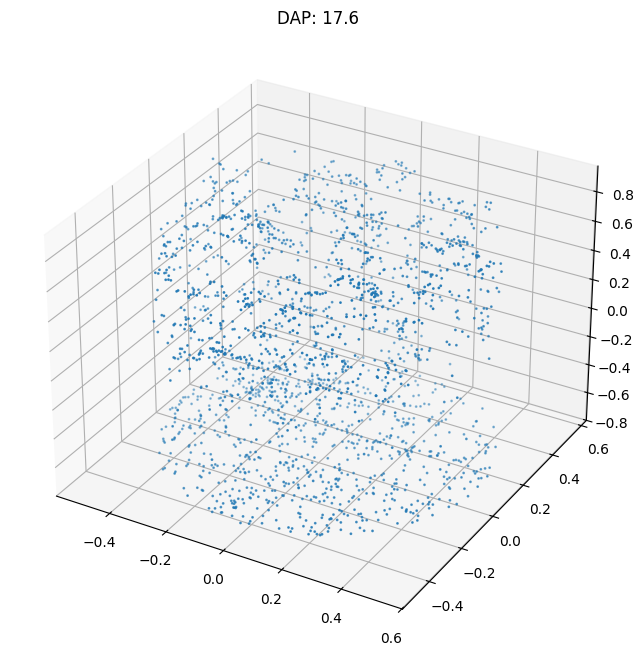

In [14]:
import matplotlib.pyplot as plt
# Plotamos uma parcela para mostrar a quantidade de pontos
sample = X_points[0]

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    sample[:,0],
    sample[:,1],
    sample[:,2],
    s=1
)

plt.title(
    f"DAP: {y_dap[0]}"
)

plt.show()

In [15]:
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import time
import psutil
import os


# ============================================================
# K-FOLD
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(kf.split(X_points))


# ============================================================
# MODELO POINTNET
# ============================================================

class PointNetRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        self.mlp1 = nn.Conv1d(3, 64, 1)
        self.mlp2 = nn.Conv1d(64, 128, 1)
        self.mlp3 = nn.Conv1d(128, 256, 1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        # [batch, points, xyz]
        x = x.transpose(1, 2)

        x = F.relu(self.mlp1(x))
        x = F.relu(self.mlp2(x))
        x = F.relu(self.mlp3(x))

        # Global Max Pooling
        x = torch.max(x, dim=2)[0]

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x


# ============================================================
# LISTAS PARA ARMAZENAR RESULTADOS
# ============================================================

results = []

all_targets = []
all_predictions = []
all_fold_ids = []
all_parcelas = []
all_talhoes = []


# ============================================================
# K-FOLD CROSS VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(folds):

    print("\n" + "="*50)
    print(f"FOLD {fold+1}")
    print("="*50)

    # --------------------------------------------------------
    # Separação treino / teste
    # --------------------------------------------------------

    X_train = X_points[train_idx]
    X_test = X_points[test_idx]

    y_train = y_dap[train_idx]
    y_test = y_dap[test_idx]

    parcelas_test = parcelas_ids[test_idx]
    talhoes_test = talhoes_ids[test_idx]


    # --------------------------------------------------------
    # Tensor
    # --------------------------------------------------------

    X_train = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train = torch.tensor(
        y_train,
        dtype=torch.float32
    ).view(-1, 1)

    y_test = torch.tensor(
        y_test,
        dtype=torch.float32
    ).view(-1, 1)


    # --------------------------------------------------------
    # DataLoader
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train,
        y_train
    )

    test_dataset = TensorDataset(
        X_test,
        y_test
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=2,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=2,
        shuffle=False
    )


    # --------------------------------------------------------
    # Modelo
    # --------------------------------------------------------

    model = PointNetRegressor()

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )


    # --------------------------------------------------------
    # Treinamento
    # --------------------------------------------------------

    start_train = time.time()

    train_losses = []

    num_epochs = 50

    for epoch in range(num_epochs):

        model.train()

        epoch_loss = 0

        for points, targets in train_loader:

            optimizer.zero_grad()

            outputs = model(points)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = (
            epoch_loss /
            len(train_loader)
        )

        train_losses.append(avg_loss)


    end_train = time.time()

    training_time = end_train - start_train


    # ========================================================
    # PREDIÇÕES
    # ========================================================

    predictions = []
    targets = []

    start_inf = time.time()

    model.eval()

    with torch.no_grad():

        for points, labels in test_loader:

            outputs = model(points)

            predictions.extend(
                outputs.cpu().numpy().flatten()
            )

            targets.extend(
                labels.cpu().numpy().flatten()
            )

    end_inf = time.time()


    # ========================================================
    # MÉTRICAS
    # ========================================================

    total_inf_time = end_inf - start_inf

    latency = (
        total_inf_time /
        len(test_dataset)
    )

    throughput = (
        len(test_dataset) /
        total_inf_time
    )

    fps = 1 / latency

    mae = mean_absolute_error(
        targets,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            targets,
            predictions
        )
    )

    targets_array = np.array(targets)
    predictions_array = np.array(predictions)

    mape = np.mean(
        np.abs(
            (targets_array - predictions_array)
            / targets_array
        )
    ) * 100

    bias = np.mean(
        predictions_array -
        targets_array
    )

    rrmse = (
        rmse /
        np.mean(targets_array)
    ) * 100


    # ========================================================
    # MEMÓRIA E PARÂMETROS
    # ========================================================

    process = psutil.Process(
        os.getpid()
    )

    memory_mb = (
        process.memory_info().rss /
        1024**2
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )


    # ========================================================
    # SALVAR PREDIÇÕES
    # ========================================================

    all_targets.extend(targets)

    all_predictions.extend(predictions)

    all_fold_ids.extend(
        [fold + 1] *
        len(targets)
    )

    all_parcelas.extend(
        parcelas_test.tolist()
    )

    all_talhoes.extend(
        talhoes_test.tolist()
    )


    # ========================================================
    # RESULTADOS DO FOLD
    # ========================================================

    results.append({

        "fold": fold + 1,

        "mae": mae,

        "rmse": rmse,

        "mape": mape,

        "bias": bias,

        "rrmse": rrmse,

        "latency": latency,

        "throughput": throughput,

        "fps": fps,

        "memory_mb": memory_mb,

        "params": total_params,

        "training_time": training_time

    })


    print(
        f"MAE  = {mae:.3f} cm"
    )

    print(
        f"RMSE = {rmse:.3f} cm"
    )

    print(
        f"Fold {fold+1}: "
        f"{len(predictions)} predições"
    )


# ============================================================
# TABELA COM TODAS AS PREDIÇÕES
# ============================================================

predictions_df = pd.DataFrame({

    "talhao": all_talhoes,

    "parcela": all_parcelas,

    "fold": all_fold_ids,

    "DAP_real_cm": all_targets,

    "DAP_predito_cm": all_predictions

})


# ============================================================
# ERROS
# ============================================================

predictions_df["erro_cm"] = (
    predictions_df["DAP_predito_cm"]
    -
    predictions_df["DAP_real_cm"]
)

predictions_df["erro_abs_cm"] = (
    predictions_df["erro_cm"]
    .abs()
)

predictions_df["erro_percentual"] = (
    predictions_df["erro_abs_cm"]
    /
    predictions_df["DAP_real_cm"]
    * 100
)


# ============================================================
# ORDENAR POR TALHÃO E PARCELA
# ============================================================

predictions_df = predictions_df.sort_values(
    ["talhao", "parcela"]
).reset_index(drop=True)


# ============================================================
# MOSTRAR
# ============================================================

display(predictions_df)


FOLD 1
MAE  = 1.330 cm
RMSE = 1.330 cm
Fold 1: 3 predições

FOLD 2
MAE  = 1.439 cm
RMSE = 1.558 cm
Fold 2: 3 predições

FOLD 3
MAE  = 3.254 cm
RMSE = 3.351 cm
Fold 3: 3 predições

FOLD 4
MAE  = 0.287 cm
RMSE = 0.347 cm
Fold 4: 2 predições

FOLD 5
MAE  = 1.294 cm
RMSE = 1.597 cm
Fold 5: 2 predições


,talhao,parcela,fold,DAP_real_cm,DAP_predito_cm,erro_cm,erro_abs_cm,erro_percentual
0,001,001,1,17.600000,16.321239,-1.278761,1.278761,7.265687
1,001,002,3,16.799999,14.501245,-2.298754,2.298754,13.683059
2,002,006,2,13.800000,15.117525,1.317525,1.317525,9.547282
3,002,007,5,16.000000,16.357531,0.357531,0.357531,2.234566
4,004,004,3,12.900000,16.110371,3.210371,3.210371,24.886599
5,004,005,2,13.800000,14.578379,0.778378,0.778378,5.640424
6,005,008,5,17.600000,15.370075,-2.229925,2.229925,12.670030
7,005,009,4,16.700001,16.608925,-0.091076,0.091076,0.545365
8,006,010,2,17.799999,15.577907,-2.222093,2.222093,12.483666
9,006,011,1,17.000000,15.648547,-1.351453,1.351453,7.949723


In [ ]:
predictions_df.to_csv(
    "/content/drive/MyDrive/IoT/Dados/SaoManuel/PointNet_predictions_5fold.csv",
    index=False
)

print("Predições salvas com sucesso!")

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(
    predictions_df["DAP_real_cm"],
    predictions_df["DAP_predito_cm"],
    s=60
)

mn = min(
    predictions_df["DAP_real_cm"].min(),
    predictions_df["DAP_predito_cm"].min()
)

mx = max(
    predictions_df["DAP_real_cm"].max(),
    predictions_df["DAP_predito_cm"].max()
)

plt.plot(
    [mn, mx],
    [mn, mx],
    'k--',
    label="Ideal"
)

plt.xlabel("DAP real (cm)")
plt.ylabel("DAP predito (cm)")

plt.title(
    "PointNet — Predições Out-of-Fold"
)

plt.legend()
plt.grid()

plt.show()